# Linear Regression Model from Scratch

This project contains an implementation of a Linear Regression model from scratch in Python, as well as an example usage of the model on a random dataset generated using scikit-learn.

[Tanvir Anjom Siddique](https://tanvirsweb.github.io/)

## Usage

To use the Linear Regression model, simply import the `LinearRegression` class from the `Linear_regression.py` file in your Python code, create an instance of the class, and call the `fit` method on your training data to train the model. Once the model is trained, you can use the `predict` method to make predictions on new data.

## Example

An example of using the Linear Regression model on a random dataset with multiple features can be found in the `test_model.ipynb` file. This file generates a random dataset using scikit-learn, trains a Linear Regression model using the `LinearRegression` class, and makes predictions on the test set. The predicted values are then compared to the true values to evaluate the performance of the model.

# Linear Regression Model from Scratch – Theoretical and Code Explanation

## Introduction

This project implements a **Linear Regression model from scratch in Python** using only NumPy, without relying on machine learning libraries such as scikit-learn. The purpose of this implementation is to demonstrate the **mathematical foundations, optimization process, and learning mechanism** of linear regression in a transparent and educational manner.

Linear regression is a **supervised learning algorithm** used to model the relationship between one or more independent variables (features) and a dependent variable (target) by fitting a linear equation to observed data.

> ## Mathematical Model

The linear regression hypothesis function is defined as:

**ŷ = Xw + b**

Where:

- ŷ = predicted output
- X = input feature matrix
- w = weight vector (model parameters)
- b = bias (intercept term)

For each data point:

**ŷᵢ = w₁x₁ + w₂x₂ + ... + wₙxₙ + b**

The objective of learning is to find optimal values of **w** and **b** that minimize prediction error.

## Loss Function

The model uses **Mean Squared Error (MSE)** as the loss function:

**MSE = (1/n) Σ (ŷᵢ − yᵢ)²**

This function measures the average squared difference between predicted values and actual values. Minimizing this function leads to optimal model parameters.

| Usage                         | Formula                                | Gradient w.r.t w                    |
| ----------------------------- | -------------------------------------- | ----------------------------------- |
| Gradient descent (convenient) | $(J = \frac{1}{2n}\sum(\hat{y}-y)^2)$  | $(\frac{1}{n} X^T(\hat{y}-y))$      |
| Evaluation / Python MSE       | $(MSE = \frac{1}{n}\sum(\hat{y}-y)^2)$ | multiply by 2 if computing manually |

## Optimization Method: Gradient Descent

The model is trained using **Batch Gradient Descent**, an iterative optimization algorithm that updates parameters using gradients of the loss function.

Update rules:

**w = w − α · ∂L/∂w**
<br>
**b = b − α · ∂L/∂b**

Where:

- α = learning rate
- ∂L/∂w = gradient of loss with respect to weights
- ∂L/∂b = gradient of loss with respect to bias

## Regularization (Penalty Terms)

The implementation supports optional regularization to prevent overfitting:

### L1 Regularization (Lasso)

Adds sparsity by shrinking some weights to zero:

**Penalty = λ Σ |w|**

Gradient term:

**λ · sign(w)**

### L2 Regularization (Ridge)

Prevents large weights by penalizing squared magnitudes:

**Penalty = λ Σ w²**

Gradient term:

**2λw**


In [132]:
!echo ---

---


> ## Code Structure Explanation

### Class Initialization

```python
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000, penalty = None):
```

Parameters:

- `lr` → learning rate (step size of gradient descent)
- `n_iters` → number of training iterations
- `penalty` → regularization type (`None`, `'l1'`, `'l2'`)

### Training Method (`fit`)

```python
n_samples, n_features = X.shape
self.weights = np.zeros(n_features)
self.bias = 0
```

Initializes:

- weights as zeros
- bias as zero

This ensures neutral starting conditions for learning.

### Prediction Calculation

```python
y_pred = np.dot(X, self.weights) + self.bias
```

Implements the linear hypothesis function:

**ŷ = Xw + b**

### Gradient Computation

```python
dw = (1/n_samples) * (np.dot(X.T, (y_pred - y)))
db = (1/n_samples) * (np.sum(y_pred - y))
```

These are the partial derivatives of the MSE loss:

**∂L/∂w = (1/n) Xᵀ(ŷ − y)**
<br>
**∂L/∂b = (1/n) Σ(ŷ − y)**


<details>
<summary><strong>Step-by-Step Gradient Derivation from MSE Cost</strong></summary>

### 1. Start with the cost function

For linear regression, the cost function (Mean Squared Error) is:

$$
J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

Where:

- ( \hat{y}\_i = w^T x_i + b ) is the predicted value
- ( y_i ) is the actual value
- ( n ) is the number of samples

The ( 1/2n ) factor is used to simplify derivatives later.

### 2. Define the error vector

Define the error for each sample:

$$
e_i = \hat{y}_i - y_i
$$

Then the cost function becomes:

$$
J(w, b) = \frac{1}{2n} \sum_{i=1}^n e_i^2
$$

### 3. Partial derivative with respect to weights ( w )

For a single sample:

$$
\hat{y}_i = w^T x_i + b \quad \Rightarrow \quad \frac{\partial \hat{y}_i}{\partial w} = x_i
$$

Derivative of squared error:

$$
\frac{\partial}{\partial w} (\hat{y}_i - y_i)^2 = 2 (\hat{y}_i - y_i) x_i
$$

For all samples:

$$
\frac{\partial J}{\partial w} = \frac{1}{2n} \sum_{i=1}^n 2 (\hat{y}_i - y_i) x_i
$$

Simplify ( 2 / 2n ):

$$
\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i) x_i
$$

In vector form:

$$
\frac{\partial J}{\partial w} = \frac{1}{n} X^T (\hat{y} - y)
$$

This matches the code:

```python
dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
```

### 4. Partial derivative with respect to bias ( b )

Bias has no feature, so:

$$
\frac{\partial J}{\partial b} = \frac{1}{2n} \sum_{i=1}^n 2 (\hat{y}*i - y_i) = \frac{1}{n} \sum*{i=1}^n (\hat{y}_i - y_i)
$$

Matches the code:

```python
db = (1/n_samples) * np.sum(y_pred - y)
```

### 5. Summary

1. Start with $( J = \frac{1}{2n} \sum (\hat{y}-y)^2 )$
2. Take derivative w.r.t each parameter
3. Factor of 2 cancels with 1/2 → simplified formulas
4. Vector form gives compact gradient update for all samples

</details>


> ### Regularization Integration

```python
if self.penalty == 'l1':
    dw += self.lr * np.sign(self.weights)
elif self.penalty == 'l2':
    dw += self.lr * 2 * self.weights
```

Adds penalty gradients to the weight update equation, implementing L1 or L2 regularization.

<details>
 <summary><strong> Why Regularization is Added in Gradient Calculation (L1 and L2 Explained)</strong></summary>

### Why Regularization is Needed

In linear regression, the model learns weights by minimizing the Mean Squared Error:

$$
L_{MSE}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

If the model is allowed to freely adjust weights, some weights may become very large.  
Large weights often mean the model is fitting noise instead of real patterns.  
This causes **overfitting**.

Regularization solves this by adding a penalty on large weights.

---

### Regularized Loss Function

Instead of minimizing only MSE, we minimize

$$
L = L_{MSE} + \text{Penalty}
$$

---

### L1 Regularization (Lasso)

Penalty:

$$
\lambda \sum |w|
$$

Full loss:

$$
L=\frac{1}{n}\sum (\hat{y}-y)^2+\lambda\sum |w|
$$

Derivative of the L1 term:

$$
\frac{\partial}{\partial w}|w|=\text{sign}(w)
$$

So gradient becomes:

$$
\nabla_w = \text{MSE gradient} + \lambda \, \text{sign}(w)
$$

##### use of `\text{sign}(w)'

- Positive weight → derivative = +1 → gradient pushes weight down

- Negative weight → derivative = -1 → gradient pushes weight up

- Zero weight → derivative = 0 → weight stays zero

---

### L2 Regularization (Ridge)

Penalty:

$$
\lambda \sum w^2
$$

Full loss:

$$
L=\frac{1}{n}\sum (\hat{y}-y)^2+\lambda\sum w^2
$$

Derivative:

$$
\frac{\partial}{\partial w}(w^2)=2w
$$

So gradient becomes:

$$
\nabla_w = \text{MSE gradient} + 2\lambda w
$$

---

### How This Appears in the Code

Your gradient without regularization is:

```python
dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
```

Regularization simply **adds an extra gradient term**.

That is why the implementation does:

```python
if self.penalty == 'l1':
    dw += self.lr * np.sign(self.weights)
elif self.penalty == 'l2':
    dw += self.lr * 2 * self.weights
```

---

### What Each Line Means

#### L1 case

```python
dw += self.lr * np.sign(self.weights)
```

This adds the derivative of

$$
\lambda |w|
$$

The `sign()` function returns:

- +1 if weight positive
- −1 if weight negative
- 0 if weight zero

This pushes weights toward zero and can force some weights to become exactly zero.
That is why L1 performs **feature selection**.

---

#### L2 case

```python
dw += self.lr * 2 * self.weights
```

This adds the derivative of

$$
\lambda w^2
$$

This continuously shrinks weights toward zero but rarely makes them exactly zero.

So L2 performs **weight shrinking**, not feature removal.

---

### Important Concept for Students

Regularization does NOT change prediction directly.

It only changes how weights update during training.

Gradient descent update is:

$$
w = w - \alpha \nabla_w
$$

Regularization modifies the gradient

$$
\nabla_w = \text{original gradient} + \text{penalty gradient}
$$

---

### Simple Intuition

Without regularization:

> choose weights that best fit data

With regularization:

> choose weights that fit data **and remain small**

---

<details>
<summary><strong>L1 vs L2 Regularization Intuition</strong></summary>

### L1 Regularization (Lasso)

- Adds penalty: $\lambda \sum |w_i|$
- Gradient uses: $\text{sign}(w_i)$ → pushes weights **directly toward zero**
- Effect: some weights become **exactly zero**, creating a **sparse model** (A sparse model simply means a model in which many of the weights are exactly zero.)
- Use when: you want **feature selection** or simpler models

### L2 Regularization (Ridge)

- Adds penalty: $\lambda \sum w_i^2$
- Gradient uses: $2 w_i$ → smoothly **shrinks all weights**
- Effect: weights become smaller but rarely exactly zero → **stable model**
- Use when: you want to **prevent large weights** without removing features

**Quick memory trick:**

- L1 → sharp zeroing → sparse
- L2 → smooth shrinking → stable

</details>

</details>

### Parameter Update

```python
self.weights = self.weights - (self.lr * dw)
self.bias = self.bias - (self.lr * db)
```

Performs gradient descent optimization to minimize the loss function.


<details>
<summary><strong>Deriving Mean Squared Error in Vector Form (Step-by-Step Explanation)</strong></summary>

### Mean Squared Error in Summation Form

The Mean Squared Error (MSE) is

$$
L=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

This means:

- subtract the true value from the prediction
- square the difference
- add all squared errors
- divide by the number of samples

### Step 1. Define the Error Vector

Instead of writing each error separately, we group all errors into one vector

$$
\mathbf{e}=\hat{\mathbf{y}}-\mathbf{y}
$$

If there are three samples,

$$
\mathbf{e}=
\begin{bmatrix}
\hat{y}_1-y_1\\
\hat{y}_2-y_2\\
\hat{y}_3-y_3
\end{bmatrix}
$$

### Step 2. Understanding eᵀe

Transpose converts the column vector into a row vector

$$
\mathbf{e}^T=
\begin{bmatrix}
e_1 & e_2 & e_3
\end{bmatrix}
$$

Now multiply

$$
\mathbf{e}^T\mathbf{e}
=
\begin{bmatrix}
e_1 & e_2 & e_3
\end{bmatrix}
\begin{bmatrix}
e_1\\
e_2\\
e_3
\end{bmatrix}
$$

Matrix multiplication produces

$$
e_1^2+e_2^2+e_3^2=\sum_i e_i^2
$$

### Step 3. Substitute Error Definition

Since

$$
e_i=\hat{y}_i-y_i
$$

we obtain

$$
\mathbf{e}^T\mathbf{e}
=\sum_i(\hat{y}_i-y_i)^2
$$

### Step 4. Divide by Number of Samples

So the loss becomes

$$
L=\frac{1}{n}\mathbf{e}^T\mathbf{e}
$$

### Simple Intuition

- summation form = school formula
- vector form = compact linear-algebra version

They are mathematically identical.

### Ultra-Short Memory Trick

$$
\text{vector}^T \times \text{vector}=\text{sum of squares}
$$

Therefore

$$
\mathbf{e}^T\mathbf{e}=\sum e_i^2
$$

</details>


In [133]:
!echo ---

---


> ### Loss Computation

```python
current_loss = np.mean(np.square(y_pred - y))
```

Computes Mean Squared Error (MSE) at each iteration.

### Convergence Condition

```python
if abs(current_loss - prev_loss) < tol:
    break
```

Implements **early stopping** based on tolerance threshold, improving efficiency and preventing unnecessary iterations.

## Prediction Method

```python
def predict(self, X):
    return np.dot(X, self.weights) + self.bias
```

Uses the learned parameters to generate predictions using the trained linear model.

## Educational Significance

This implementation demonstrates:

- Core mathematics of linear regression
- Gradient descent optimization
- Loss minimization
- Regularization techniques
- Model convergence logic
- Parameter learning dynamics

## Learning Outcomes

From this project, learners gain understanding of:

- How machine learning models learn from data
- Relationship between statistics and ML
- Optimization-based learning
- Regularization theory
- Model generalization
- Algorithmic implementation from first principles

## Conclusion

This linear regression model provides a transparent and mathematically grounded implementation of supervised learning. It serves as an educational foundation for understanding more advanced machine learning algorithms such as logistic regression, neural networks, and deep learning models, all of which build upon the same optimization and loss minimization principles.


In [134]:
!python --version
!echo Date: %date% ,Time: %time%
!echo LinkedIn Profile: https://www.linkedin.com/in/tanvir-anjom-siddique/

Python 3.13.5
Date: Wed 02/18/2026 ,Time:  1:30:37.00
LinkedIn Profile: https://www.linkedin.com/in/tanvir-anjom-siddique/


# Linear Regression with Gradient Descent

[Tanvir Anjom Siddique](https://tanvirsweb.github.io)


In [135]:

# import numpy as np

# class LinearRegression:
#     def __init__(self, lr=0.001, n_iters=1000, penalty = None):
#         self.lr = lr
#         self.n_iters = n_iters
#         self.weights = None
#         self.bias = None
#         self.penalty = penalty
    
#     def fit(self, X, y):
#         n_samples, n_features = X.shape
#         self.weights = np.zeros(n_features)
#         self.bias = 0
        
#         tol = 1e-5
#         prev_loss = 0
#         for i in range(self.n_iters):
#             y_pred = np.dot(X, self.weights) + self.bias
#             dw = (1/n_samples) * (np.dot(X.T, (y_pred - y)))
            
#             # add regularization derevitive terme
#             if self.penalty == 'l1':
#                 dw += self.lr * np.sign(self.weights)
#             elif self.penalty == 'l2':
#                 dw += self.lr * 2 * self.weights
#             db = (1/n_samples) * (np.sum(y_pred - y))
#             self.weights = self.weights - (self.lr * dw)
#             self.bias = self.bias - (self.lr * db)
            
#             current_loss = np.mean(np.square(y_pred - y))
            
#             if abs(current_loss - prev_loss) < tol:
#                 break
                
#             prev_loss = current_loss
        
#     def predict(self, X):
#         return np.dot(X, self.weights) + self.bias


In [136]:
import numpy as np

class LinearRegression:
    def __init__(self, lr=0.01, n_iters=1000, penalty=None, lambda_=0.1, tol=1e-6, verbose=False):
        """
        Initialize the Linear Regression model.
        
        Parameters:
        lr       : Learning rate for gradient descent.
        n_iters  : Maximum number of iterations for gradient descent.
        penalty  : Regularization type ('l1', 'l2', or None).
        lambda_  : Regularization strength.
        tol      : Tolerance for early stopping.
        verbose  : If True, prints loss during training.
        """
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.lambda_ = lambda_
        self.tol = tol
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Train the model using batch gradient descent.
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)  # initialize weights
        self.bias = 0                        # initialize bias

        for i in range(self.n_iters):
            # Linear prediction
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Add regularization if specified
            if self.penalty == 'l1':
                dw += self.lambda_ * np.sign(self.weights)
            elif self.penalty == 'l2':
                dw += 2 * self.lambda_ * self.weights

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Compute loss (MSE)
            loss = (1 / (2 * n_samples)) * np.sum((y_pred - y) ** 2)
            if self.penalty == 'l1':
                loss += self.lambda_ * np.sum(np.abs(self.weights))
            elif self.penalty == 'l2':
                loss += self.lambda_ * np.sum(self.weights ** 2)

            self.loss_history.append(loss)

            # Early stopping
            if i > 0 and abs(self.loss_history[-2] - loss) < self.tol:
                if self.verbose:
                    print(f"Early stopping at iteration {i}, loss change < tol")
                break
            
            # self.verbose : a flag to enable printing progress 
            # i % 100 == 0 : prints the loss every 100 iterations.
            if self.verbose and i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss:.6f}")

    def predict(self, X):
        """
        Predict target values for given input X.
        """
        return np.dot(X, self.weights) + self.bias


# Implementaion of Linear Regression on dataset


In [137]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
# from LinearRegression import LinearRegression

In [138]:
n_samples = 1000
n_features = 10

In [139]:
X, y = make_regression(n_samples=n_samples, n_features=n_features,
                       n_informative=5, noise=10, random_state=42)

In [140]:
X[:2, :]

array([[ 0.12342918, -1.25340172,  0.37034027,  0.10178833,  0.09262759,
        -0.58925373,  0.30634753, -1.45821311,  1.63012996,  1.24286256],
       [-0.21682705,  0.21498282, -0.0288166 , -1.70114047,  0.26448168,
         0.31497187,  0.37406209, -0.29275792,  0.50190023,  0.06370236]])

In [141]:
y[:2]

array([ 18.92684474, -56.46327231])

In [142]:
X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=.2, random_state=1)

### visualizes the relationship between the first feature and the target


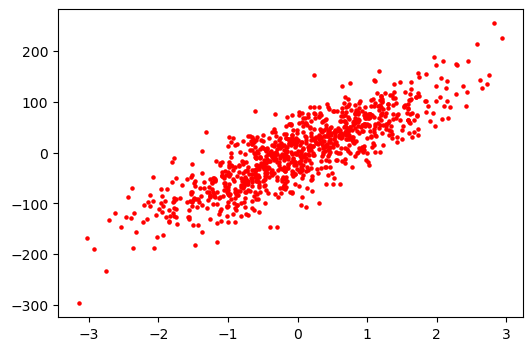

In [143]:
fig = plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], y, color="red", marker="o", s=5)
plt.show()

## MSE: Mean Square Error


In [144]:
def mse(y, predictions):
    return np.mean(np.square(y - predictions))
    # same for python skicitlearn default program

<details>
<summary><strong>Regression Metrics Explained</strong></summary>

### 1. Common Regression Metrics

1. **Mean Squared Error (MSE)**

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

Measures **average squared difference** between predicted and actual values. Lower is better.

2. **Root Mean Squared Error (RMSE)**

$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

Same units as target `y`. Easier to interpret than MSE.

3. **Mean Absolute Error (MAE)**

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\hat{y}_i - y_i|
$$

Measures average absolute difference. Less sensitive to outliers than MSE.

4. **R² Score (Coefficient of Determination)**

$$
R^2 = 1 - \frac{\sum (\hat{y}_i - y_i)^2}{\sum (y_i - \bar{y})^2}
$$

- Measures proportion of variance explained by the model.
- Range: 0–1 (closer to 1 = better fit).
- Can be negative if model is worse than simply predicting the mean.

5. **Adjusted R²** (optional for multiple features)

$$
R^2_{\text{adj}} = 1 - \frac{(1-R^2)(n-1)}{n-p-1}
$$

- Adjusts R² for number of features `p`.
- Prevents inflated R² for models with many features.

### 2. Example Python Implementation

```python
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions on validation set
y_pred_val = model.predict(X_val)

# MSE
mse_val = mean_squared_error(y_val, y_pred_val)
print("MSE:", mse_val)

# RMSE
rmse_val = np.sqrt(mse_val)
print("RMSE:", rmse_val)

# MAE
mae_val = mean_absolute_error(y_val, y_pred_val)
print("MAE:", mae_val)

# R^2 Score
r2_val = r2_score(y_val, y_pred_val)
print("R2 Score:", r2_val)

# Optional: Adjusted R^2
n = X_val.shape[0]  # number of samples
p = X_val.shape[1]  # number of features
r2_adj = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)
print("Adjusted R2:", r2_adj)
```

### 3. How to Interpret

| Metric      | Ideal Value | What It Tells                               |
| ----------- | ----------- | ------------------------------------------- |
| MSE         | 0           | Average squared error                       |
| RMSE        | 0           | Error in same units as target               |
| MAE         | 0           | Average absolute error, robust to outliers  |
| R²          | 1           | Fraction of variance explained by the model |
| Adjusted R² | 1           | R² corrected for number of features         |

</details>


## Train Model


In [145]:
model = LinearRegression(lr=0.01)
model.fit(X_fit, y_fit)
train_predictions = model.predict(X_fit)

In [146]:
mse(y_fit, train_predictions)

np.float64(99.49443612637322)

## Predict with model


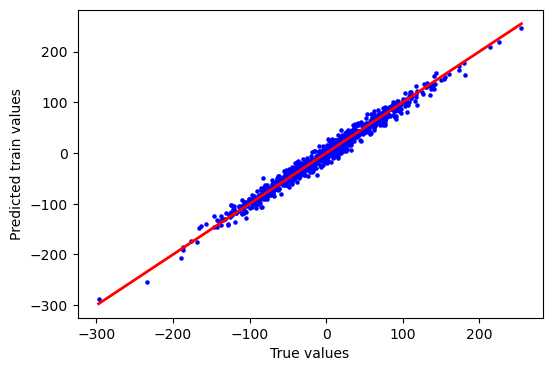

In [147]:
y_pred_train = model.predict(X_fit)

fig = plt.figure(figsize=(6,4))
plt.scatter(y_fit, y_pred_train, color="blue", s=5)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted train values")
plt.show()

84.53592409251432


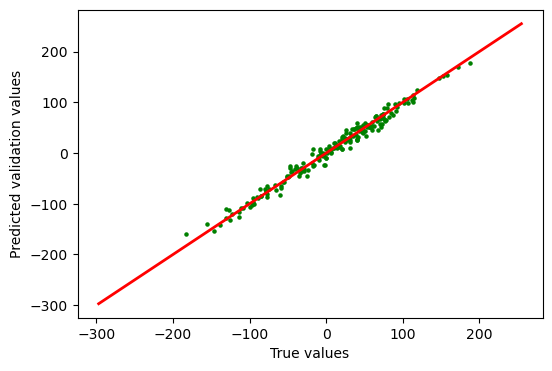

In [148]:
y_pred_val = model.predict(X_val)

print(mse(y_pred_val, y_val))

fig = plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_val, color="green", s=5)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted validation values")
plt.show()

# Now trying using L2 regularization


In [149]:
model = LinearRegression(lr=0.01, penalty="l2")
model.fit(X_fit, y_fit)
train_predictions = model.predict(X_fit)

In [150]:
mse(y_fit, train_predictions)

np.float64(228.44113658784042)

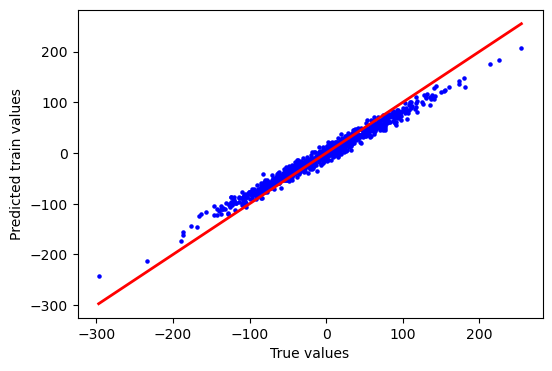

In [151]:
y_pred_train = model.predict(X_fit)

fig = plt.figure(figsize=(6,4))
plt.scatter(y_fit, y_pred_train, color="blue", s=5)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted train values")
plt.show()

224.57822739387274


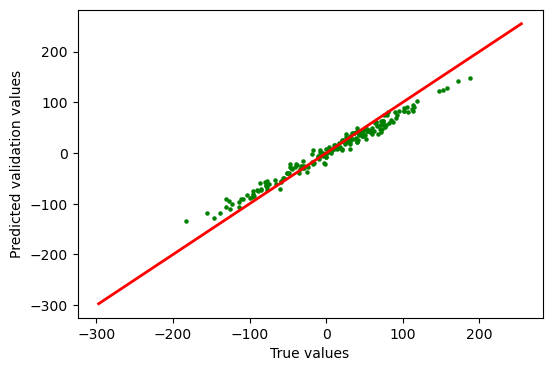

In [152]:
y_pred_val = model.predict(X_val)

print(mse(y_pred_val, y_val))

fig = plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_val, color="green", s=5)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted validation values")
plt.show()